**Student Name:** Diksha Sharma

**Student ID:** c096344

**Course:** AML 3303

## 1. Context and Problem Statement

MapleFreight Logistics handles approximately 8,000 shipments per week across Ontario, Quebec, and the Prairies. The company provides on-time delivery guarantees to its customers, meaning late deliveries can result in service credits, re-delivery costs, and customer dissatisfaction.

The company's on-time delivery performance has decreased from 94% to 88%. Currently, shipment delays are often identified only after the promised delivery window has passed, leaving dispatch with little opportunity to take corrective action.

The purpose of this project is to develop an end-to-end machine learning system that predicts whether an in-transit shipment is at risk of being delivered late. High-risk shipments can then be communicated to the dispatch team through Slack, allowing dispatch to take proactive actions such as re-routing shipments or notifying customers.

## 2. Objectives

The main objectives of this project are:

1. Analyze shipment, route, carrier, weather, and operational data to identify the main factors associated with late deliveries.
2. Clean and preprocess the raw shipment data by handling missing values, duplicates, inconsistent categories, and possible unit errors.
3. Build a baseline classification model to predict whether a shipment will be delivered late.
4. Develop and compare an improved machine learning model against the baseline.
5. Evaluate model performance using precision, recall, F1-score, and a confusion matrix.
6. Select and justify an appropriate probability threshold for identifying high-risk shipments.
7. Explain the factors that contribute most to late-delivery predictions.
8. Integrate Slack alerts to automatically notify dispatch about high-risk shipments.
9. Provide actionable recommendations to help MapleFreight improve its on-time delivery performance.

## 3. Data Understanding

In this section, the MapleFreight shipment dataset is loaded and examined to understand its structure, features, data types, and overall quality before performing data cleaning and exploratory analysis.

In [64]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\sharm\Assignment1-Dikshasharma26
['.env', '.env.example', '.git', '.gitignore', '.ipynb_checkpoints', 'Assignment1_Starter.ipynb', 'data', 'MapleFreight_Delivery_Delay_Prediction_c0965344.ipynb', 'notebook', 'README.md', 'README_old_social_media.md', 'Report', 'requirements.txt', 'screenshots']


In [65]:
# Import required library
import pandas as pd

# Load the MapleFreight shipment dataset
df = pd.read_csv("notebook/maplefreight_delivery_delay_dataset.csv")

# Display the first five rows
df.head()

,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


In [66]:
# Check the dimensions of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6035
Number of columns: 23


### Finding

The raw MapleFreight dataset contains **6,035 shipment records and 23 columns**. The dataset includes shipment, route, carrier, service, weather, traffic, vehicle, driver, and delivery-related information. The target variable for the prediction task is `delivered_late`.

In [67]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   shipment_id                6035 non-null   object 
 1   origin_city                6035 non-null   object 
 2   destination_city           6035 non-null   object 
 3   carrier                    6035 non-null   object 
 4   service_level              6035 non-null   object 
 5   goods_type                 6035 non-null   object 
 6   customer_priority_tier     6035 non-null   object 
 7   shipment_month             6035 non-null   int64  
 8   distance_km                6035 non-null   float64
 9   weight_kg                  6035 non-null   float64
 10  num_stops                  6035 non-null   int64  
 11  is_cross_border            6035 non-null   int64  
 12  scheduled_transit_hours    6035 non-null   float64
 13  pickup_delay_minutes       6035 non-null   float

In [68]:
# Display all column names
df.columns.tolist()

['shipment_id',
 'origin_city',
 'destination_city',
 'carrier',
 'service_level',
 'goods_type',
 'customer_priority_tier',
 'shipment_month',
 'distance_km',
 'weight_kg',
 'num_stops',
 'is_cross_border',
 'scheduled_transit_hours',
 'pickup_delay_minutes',
 'driver_experience_years',
 'vehicle_age_years',
 'weather_condition',
 'traffic_index',
 'route_congestion_score',
 'prior_late_deliveries_30d',
 'fuel_cost_cad',
 'actual_transit_hours',
 'delivered_late']

### Finding

The dataset contains a combination of numerical and categorical variables. These features describe shipment characteristics, routes, carriers, service levels, operating conditions, drivers, vehicles, weather, and traffic.

The target variable is `delivered_late`, where **1 represents a late delivery and 0 represents an on-time delivery**.

The `actual_transit_hours` variable represents the actual delivery time recorded after delivery. Therefore, it will **not be used as a predictor**, because this information would not be available when predicting the risk of an in-transit shipment. Including it would cause data leakage.


In [69]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Display only columns that contain missing values
missing_values[missing_values > 0]

driver_experience_years    210
weather_condition          150
traffic_index              121
fuel_cost_cad              240
dtype: int64

### Missing Values Finding

Missing values were identified in four variables:

- `driver_experience_years`: 210 missing values
- `weather_condition`: 150 missing values
- `traffic_index`: 121 missing values
- `fuel_cost_cad`: 240 missing values

These missing values will be handled during the data preprocessing stage. Numerical variables will be evaluated for an appropriate imputation strategy, while the categorical `weather_condition` variable will be handled separately. The rows are not removed at this stage because unnecessary deletion could result in loss of useful shipment information.

In [70]:
# Check for exact duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 32


### Duplicate Records Finding

The dataset contains **32 exact duplicate rows**. Duplicate records can bias the analysis and model training by giving repeated observations additional influence. These duplicates will therefore be removed during the data-cleaning stage while retaining one copy of each shipment record.

In [71]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Display unique values for each categorical column
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


shipment_id:
['SHP-103848' 'SHP-102827' 'SHP-105254' ... 'SHP-105201' 'SHP-103776'
 'SHP-101946']

origin_city:
['Mississauga ON' 'Montreal QC' 'Toronto ON' 'London ON' 'Calgary AB'
 'Winnipeg MB' 'Ottawa ON']

destination_city:
['Edmonton AB' 'Winnipeg MB' 'Hamilton ON' 'Sudbury ON' 'Toronto ON'
 'Quebec City QC' 'Regina SK' 'Calgary AB' 'Ottawa ON' 'Montreal QC']

carrier:
['NorthStar Carriers' 'PrairieLine' 'QuebecExpress' 'MapleFreight Fleet'
 'Contract Owner-Op']

service_level:
['Standard' 'Express' 'Economy' 'standard' 'economy' 'express']

goods_type:
['General Freight' 'Fragile' 'Refrigerated' 'Bulk' 'Hazardous']

customer_priority_tier:
['Bronze' 'Silver' 'Gold']

weather_condition:
['Fog' 'Snow' 'Rain' 'Clear' 'Storm' nan]


### Categorical Data Quality Finding

Inspection of the categorical variables revealed inconsistent capitalization in the `service_level` column. For example, values such as `Standard` and `standard`, `Express` and `express`, and `Economy` and `economy` represent the same service levels but are stored differently.

These values must be standardized during data cleaning so that each service level is represented by a single consistent category.

In [72]:
# Generate descriptive statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
shipment_month,6035.0,6.543662,3.448260,1.00,4.000,7.000,10.000,12.00
distance_km,6035.0,632.192742,319.246133,80.50,398.600,571.100,804.850,2556.70
weight_kg,6035.0,6928.251135,83755.149685,30.00,496.000,827.100,1286.300,2999300.00
num_stops,6035.0,2.477051,1.707457,0.00,1.000,2.000,4.000,5.00
is_cross_border,6035.0,0.113007,0.316628,0.00,0.000,0.000,0.000,1.00
scheduled_transit_hours,6035.0,10.500388,4.758576,1.00,7.060,9.850,13.175,37.40
pickup_delay_minutes,6035.0,20.367688,30.618617,-20.00,-6.000,18.000,41.000,146.00
driver_experience_years,5825.0,6.497648,4.659277,0.20,3.200,5.400,8.600,35.00
vehicle_age_years,6035.0,5.489461,3.433676,0.10,3.000,4.800,7.200,20.00
traffic_index,5914.0,55.146365,17.592978,5.00,43.300,55.000,67.200,100.00


In [73]:
# Investigate suspiciously large shipment weights
high_weight_shipments = df[df["weight_kg"] > 10000]

print("Number of shipments with weight above 10,000 kg:",
      len(high_weight_shipments))

high_weight_shipments[
    ["shipment_id", "goods_type", "weight_kg"]
].sort_values("weight_kg", ascending=False)

Number of shipments with weight above 10,000 kg: 40


,shipment_id,goods_type,weight_kg
2323,SHP-102944,Hazardous,2999300.0
846,SHP-101687,General Freight,1593600.0
1525,SHP-102395,General Freight,1554700.0
3284,SHP-100634,General Freight,1408300.0
4761,SHP-104016,General Freight,1389500.0
696,SHP-100641,General Freight,1332200.0
4028,SHP-103017,General Freight,1246100.0
4876,SHP-104749,Fragile,1238200.0
4024,SHP-100891,Refrigerated,1227100.0
1030,SHP-102384,General Freight,1209400.0


In [74]:
# Count suspected weight unit errors
weight_unit_errors = (df["weight_kg"] > 10000).sum()

print("Suspected weight unit errors:", weight_unit_errors)

Suspected weight unit errors: 40


### Weight Unit Error Finding

The descriptive statistics revealed unusually large values in `weight_kg`. While the median shipment weight is approximately **827 kg**, the maximum recorded weight is **2,999,300 kg**.

Further investigation identified **40 shipments with weights above 10,000 kg**. The affected values are several hundred thousand to several million, which is inconsistent with the typical shipment weights in the dataset. These values appear to have been recorded in **grams rather than kilograms**.

For example, a recorded value of 1,593,600 would correspond to 1,593.6 kg after conversion from grams to kilograms. Therefore, these 40 suspected unit errors will be corrected during the data-cleaning stage by dividing the affected values by 1,000.

In [75]:
# Check the distribution of the target variable
target_counts = df["delivered_late"].value_counts()
target_percentages = df["delivered_late"].value_counts(normalize=True) * 100

print("Target Counts:")
print(target_counts)

print("\nTarget Percentages:")
print(target_percentages.round(2))

Target Counts:
delivered_late
0    4793
1    1242
Name: count, dtype: int64

Target Percentages:
delivered_late
0    79.42
1    20.58
Name: proportion, dtype: float64


### Target Distribution Finding

The target variable `delivered_late` is imbalanced:

- **4,793 shipments (79.42%)** were delivered on time.
- **1,242 shipments (20.58%)** were delivered late.

This class imbalance is important for model development. A model that predicts every shipment as on time could achieve approximately **79.42% accuracy** without identifying any late shipments.

Therefore, model performance will not be evaluated using accuracy alone. Metrics such as **precision, recall, F1-score, and the confusion matrix** will be used, with particular attention to the model's ability to identify late deliveries.

## 4. Data Cleaning and Preprocessing

The initial data assessment identified duplicate records, inconsistent categorical values, weight unit errors, and missing values. These issues are addressed in this section to prepare reliable data for exploratory analysis and machine learning.

In [76]:
# Remove exact duplicate rows
rows_before = df.shape[0]

df = df.drop_duplicates().copy()

rows_after = df.shape[0]

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before removing duplicates: 6035
Rows after removing duplicates: 6003
Duplicates removed: 32


### Duplicate Removal

A total of **32 exact duplicate records** were removed from the dataset. The number of records decreased from **6,035 to 6,003**. Removing duplicates prevents repeated shipments from having unnecessary influence on the exploratory analysis and model training.

In [77]:
# Check service level categories before cleaning
print("Before cleaning:")
print(df["service_level"].value_counts())

Before cleaning:
service_level
Standard    3204
Express     1433
Economy     1246
standard      74
express       27
economy       19
Name: count, dtype: int64


In [78]:
# Standardize service_level categories
df["service_level"] = (
    df["service_level"]
    .str.strip()
    .str.title()
)

# Check categories after cleaning
print("After cleaning:")
print(df["service_level"].value_counts())

After cleaning:
service_level
Standard    3278
Express     1460
Economy     1265
Name: count, dtype: int64


### Service Level Standardization

The `service_level` column contained inconsistent capitalization, causing equivalent categories to be represented differently. The values were standardized by removing unnecessary spaces and applying consistent title-case formatting.

After cleaning, the column contains three consistent service-level categories: **Standard, Express, and Economy**. This prevents the machine learning model from incorrectly treating differently formatted versions of the same service level as separate categories.

In [79]:
# Correct suspected weight unit errors
weight_error_mask = df["weight_kg"] > 10000

print("Weight values corrected:", weight_error_mask.sum())

# Convert suspected gram values to kilograms
df.loc[weight_error_mask, "weight_kg"] = (
    df.loc[weight_error_mask, "weight_kg"] / 1000
)

# Verify the corrected weight distribution
print("\nWeight statistics after correction:")
print(df["weight_kg"].describe())

Weight values corrected: 40

Weight statistics after correction:
count    6003.000000
mean      953.683458
std       618.324081
min        30.000000
25%       494.500000
50%       823.300000
75%      1274.200000
max      5044.000000
Name: weight_kg, dtype: float64


### Weight Unit Correction

A total of **40 shipment records** contained suspected weight unit errors, with values above 10,000 kg. Based on the distribution of the data, these records appeared to have been stored in grams rather than kilograms.

The affected values were converted to kilograms by dividing them by 1,000. After correction, the mean shipment weight is approximately **953.68 kg**, the median is **823.30 kg**, and the maximum is **5,044 kg**. The corrected distribution is substantially more consistent with the remaining shipment records.

In [80]:
# Recheck missing values after duplicate removal
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percent
driver_experience_years,210,3.5
weather_condition,150,2.5
traffic_index,120,2.0
fuel_cost_cad,240,4.0


### Missing Value Treatment

Four variables contain missing values after duplicate removal. Rather than deleting these records and losing potentially useful shipment information, missing values will be imputed.

For the numerical variables `driver_experience_years`, `traffic_index`, and `fuel_cost_cad`, the **median** will be used because it is less sensitive to extreme values than the mean.

For the categorical variable `weather_condition`, the **mode (most frequent category)** will be used.

In [81]:
# Fill missing numerical values using the median
numeric_missing_columns = [
    "driver_experience_years",
    "traffic_index",
    "fuel_cost_cad"
]

for column in numeric_missing_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing weather conditions using the mode
df["weather_condition"] = df["weather_condition"].fillna(
    df["weather_condition"].mode()[0]
)

# Verify that no missing values remain
print("Total missing values after imputation:", df.isnull().sum().sum())

Total missing values after imputation: 0


In [82]:
# Final verification of the cleaned dataset
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("Service levels:", df["service_level"].unique())
print("Maximum weight (kg):", df["weight_kg"].max())

Dataset shape: (6003, 23)
Duplicate rows: 2
Missing values: 0
Service levels: ['Standard' 'Express' 'Economy']
Maximum weight (kg): 5044.0


### Data Cleaning Summary

The data-cleaning process successfully prepared the dataset for analysis and modelling. A total of **32 duplicate records** were removed, inconsistent `service_level` categories were standardized, **40 suspected weight unit errors** were corrected, and all missing values were imputed.

The cleaned dataset contains **6,003 shipment records and 23 variables**, with no exact duplicate rows or missing values remaining. The cleaned data is now ready for exploratory data analysis.

## 5. Exploratory Data Analysis (EDA)

Exploratory data analysis is performed to understand the patterns associated with late deliveries and identify potential factors that may help predict delivery risk. The analysis focuses on the target distribution and relationships between delivery outcomes and operational factors such as weather, carrier, service level, pickup delays, traffic, and route conditions.

In [83]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visualization style
sns.set_theme(style="whitegrid")

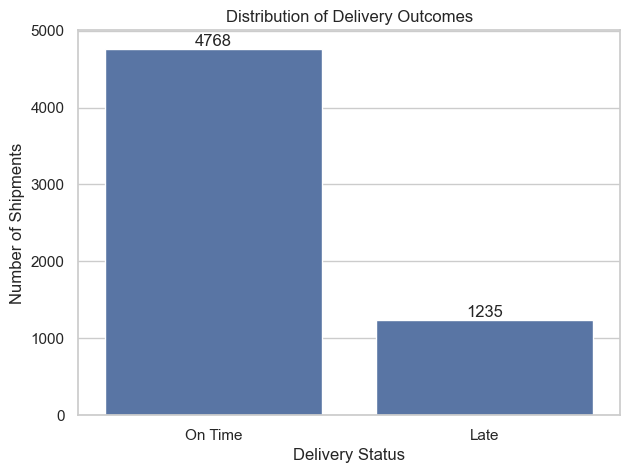

In [84]:
# Visualize the distribution of on-time and late deliveries
target_labels = df["delivered_late"].map({
    0: "On Time",
    1: "Late"
})

plt.figure(figsize=(7, 5))

ax = sns.countplot(x=target_labels)

plt.title("Distribution of Delivery Outcomes")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")

# Add counts above the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Finding: Delivery Outcome Distribution

The cleaned dataset contains **4,768 on-time deliveries and 1,235 late deliveries**. Late shipments therefore represent approximately **20.6%** of the cleaned dataset.

The large difference between the two classes confirms that the target variable is imbalanced. Therefore, accuracy alone would not be an appropriate measure of model performance. Recall, precision, F1-score, and the confusion matrix will be considered when evaluating the models.

weather_condition
Storm    46.48
Snow     33.60
Fog      21.00
Rain     20.74
Clear    14.45
Name: delivered_late, dtype: float64


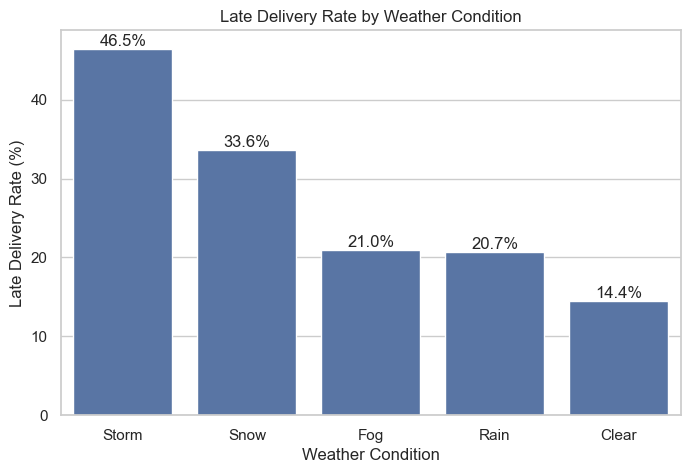

In [85]:
# Calculate late-delivery rate by weather condition
weather_late_rate = (
    df.groupby("weather_condition")["delivered_late"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(weather_late_rate.round(2))

# Visualize late-delivery rate by weather condition
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=weather_late_rate.index,
    y=weather_late_rate.values
)

plt.title("Late Delivery Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Late Delivery Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Finding: Weather Condition and Delivery Delays

Weather conditions show a clear relationship with late deliveries. Shipments dispatched during **storms have the highest late-delivery rate at 46.48%**, followed by **snow at 33.60%**.

In comparison, shipments under clear weather conditions have the lowest late-delivery rate at **14.45%**. Fog and rain have intermediate late-delivery rates of approximately 21%.

This suggests that adverse weather, particularly storms and snow, may be an important predictor of delivery delays. MapleFreight could use weather forecasts to identify higher-risk shipments and allow dispatch to take proactive action.

carrier
Contract Owner-Op     35.96
PrairieLine           26.43
QuebecExpress         22.57
NorthStar Carriers    21.93
MapleFreight Fleet    12.83
Name: delivered_late, dtype: float64


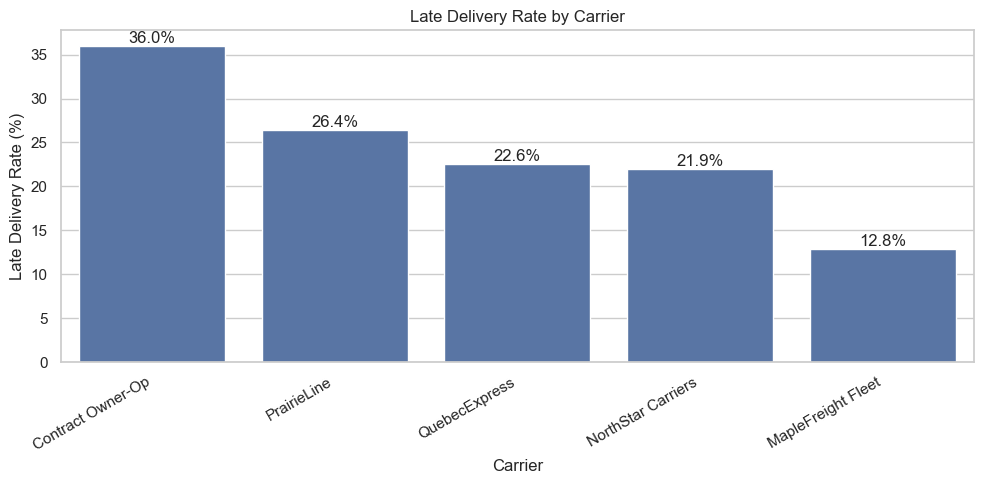

In [86]:
# Calculate late-delivery rate by carrier
carrier_late_rate = (
    df.groupby("carrier")["delivered_late"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(carrier_late_rate.round(2))

# Visualize late-delivery rate by carrier
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=carrier_late_rate.index,
    y=carrier_late_rate.values
)

plt.title("Late Delivery Rate by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Finding: Carrier and Delivery Delays

Delivery performance varies considerably across carriers. **Contract Owner-Op has the highest late-delivery rate at approximately 36.0%**, followed by PrairieLine at approximately 26.4%.

In contrast, **MapleFreight Fleet has the lowest late-delivery rate at approximately 12.8%**. QuebecExpress and NorthStar Carriers have intermediate late-delivery rates of approximately 22%.

This suggests that carrier selection may be an important factor in delivery risk. MapleFreight could monitor high-risk carriers more closely and consider carrier performance when assigning time-sensitive shipments.

service_level
Economy     26.56
Standard    20.71
Express     15.07
Name: delivered_late, dtype: float64


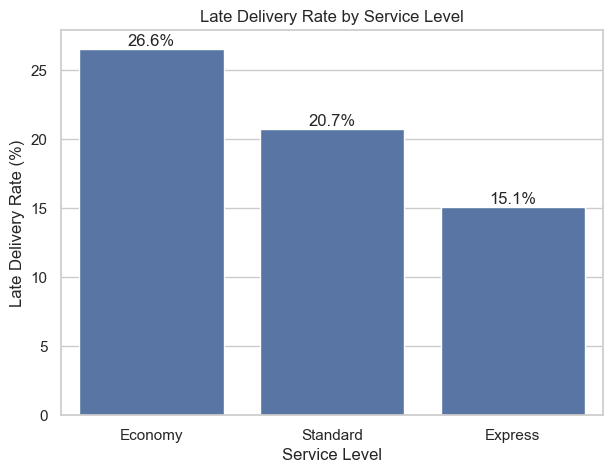

In [87]:
# Calculate late-delivery rate by service level
service_late_rate = (
    df.groupby("service_level")["delivered_late"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(service_late_rate.round(2))

# Visualize late-delivery rate by service level
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=service_late_rate.index,
    y=service_late_rate.values
)

plt.title("Late Delivery Rate by Service Level")
plt.xlabel("Service Level")
plt.ylabel("Late Delivery Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Finding: Service Level and Delivery Delays

The late-delivery rate differs across service levels. **Economy shipments have the highest late-delivery rate at 26.56%**, followed by Standard shipments at 20.71%.

**Express shipments have the lowest late-delivery rate at 15.07%**. This suggests that service level is associated with delivery performance and may provide useful information for predicting shipment delays.

MapleFreight could give additional attention to Economy shipments, particularly when other risk factors such as adverse weather or carrier performance are also present.

Average pickup delay (minutes):
delivered_late
0    18.39
1    27.91
Name: pickup_delay_minutes, dtype: float64


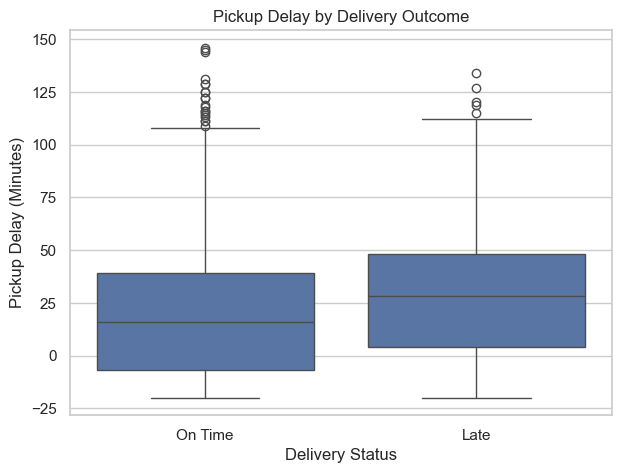

In [88]:
# Compare pickup delays for on-time and late deliveries
pickup_summary = (
    df.groupby("delivered_late")["pickup_delay_minutes"]
    .mean()
)

print("Average pickup delay (minutes):")
print(pickup_summary.round(2))

# Create readable delivery labels
plot_df = df.copy()
plot_df["delivery_status"] = plot_df["delivered_late"].map({
    0: "On Time",
    1: "Late"
})

# Visualize pickup delay by delivery outcome
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_df,
    x="delivery_status",
    y="pickup_delay_minutes"
)

plt.title("Pickup Delay by Delivery Outcome")
plt.xlabel("Delivery Status")
plt.ylabel("Pickup Delay (Minutes)")

plt.show()

### Finding: Pickup Delay and Delivery Outcome

Late deliveries experienced a higher average pickup delay than on-time deliveries. The average pickup delay was **27.91 minutes for late shipments**, compared with **18.39 minutes for on-time shipments**, a difference of approximately **9.52 minutes**.

The boxplot also shows that the distribution of pickup delays is generally higher for late deliveries, although there is some overlap between the two groups.

This suggests that pickup delay is a useful early operational indicator of delivery risk. Shipments that are already delayed at pickup may require closer monitoring or proactive intervention by dispatch.

Average traffic index:
delivered_late
0    53.68
1    60.77
Name: traffic_index, dtype: float64


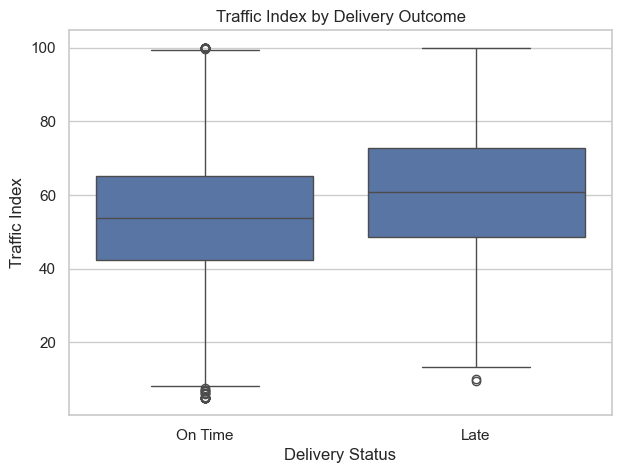

In [89]:
# Compare traffic index for on-time and late deliveries
traffic_summary = (
    df.groupby("delivered_late")["traffic_index"]
    .mean()
)

print("Average traffic index:")
print(traffic_summary.round(2))

# Visualize traffic index by delivery outcome
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_df,
    x="delivery_status",
    y="traffic_index"
)

plt.title("Traffic Index by Delivery Outcome")
plt.xlabel("Delivery Status")
plt.ylabel("Traffic Index")

plt.show()

### Finding: Traffic Conditions and Delivery Delays

Late deliveries experienced higher traffic congestion than on-time deliveries. The average traffic index was **60.77 for late shipments**, compared with **53.68 for on-time shipments**, a difference of approximately **7.09 points**.

The boxplot also shows that the traffic index distribution is generally higher for late deliveries, although the two groups overlap.

This suggests that traffic conditions are associated with delivery risk and may be useful for predicting delays. Dispatch could prioritize monitoring shipments travelling through highly congested routes.

Average route congestion score:
delivered_late
0    0.440
1    0.488
Name: route_congestion_score, dtype: float64


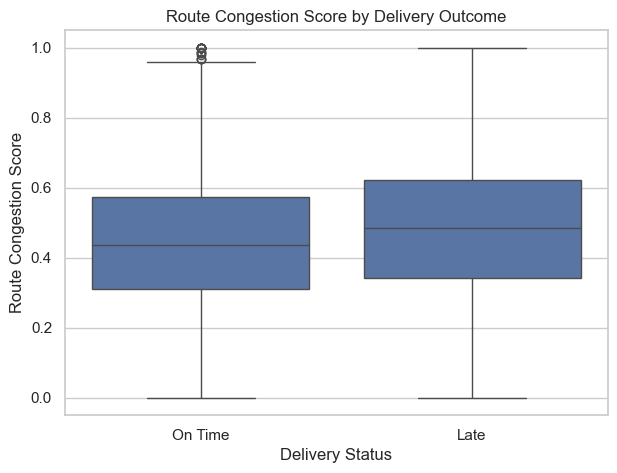

In [90]:
# Compare route congestion for on-time and late deliveries
congestion_summary = (
    df.groupby("delivered_late")["route_congestion_score"]
    .mean()
)

print("Average route congestion score:")
print(congestion_summary.round(3))

# Visualize route congestion by delivery outcome
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_df,
    x="delivery_status",
    y="route_congestion_score"
)

plt.title("Route Congestion Score by Delivery Outcome")
plt.xlabel("Delivery Status")
plt.ylabel("Route Congestion Score")

plt.show()

### Finding: Route Congestion and Delivery Delays

Late deliveries had a slightly higher average route congestion score of **0.488**, compared with **0.440 for on-time deliveries**.

The boxplot shows considerable overlap between the two groups, indicating that route congestion alone does not clearly separate late and on-time shipments. However, the higher average among late shipments suggests that route congestion may still contribute to delivery risk when combined with other factors.

Therefore, route congestion should be retained as a potential predictor for the modelling stage.

Average prior late deliveries in the past 30 days:
delivered_late
0    1.24
1    1.55
Name: prior_late_deliveries_30d, dtype: float64


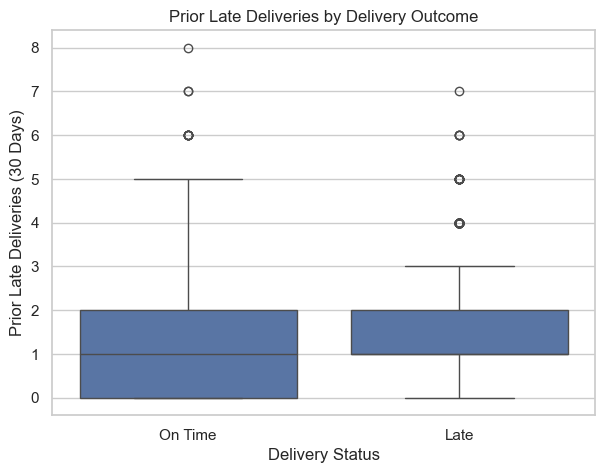

In [91]:
# Compare previous carrier delays for on-time and late shipments
prior_delay_summary = (
    df.groupby("delivered_late")["prior_late_deliveries_30d"]
    .mean()
)

print("Average prior late deliveries in the past 30 days:")
print(prior_delay_summary.round(2))

# Visualize previous carrier delays by delivery outcome
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_df,
    x="delivery_status",
    y="prior_late_deliveries_30d"
)

plt.title("Prior Late Deliveries by Delivery Outcome")
plt.xlabel("Delivery Status")
plt.ylabel("Prior Late Deliveries (30 Days)")

plt.show()

### Finding: Previous Carrier Performance and Delivery Delays

Shipments that were eventually delivered late were associated with an average of **1.55 prior late deliveries by the carrier in the previous 30 days**, compared with **1.24 for on-time shipments**.

Although the distributions overlap considerably, the higher average for late shipments suggests that recent carrier performance may provide useful information about delivery risk.

Therefore, `prior_late_deliveries_30d` will be retained as a predictor and evaluated together with the other operational features during modelling.

### EDA Summary

The exploratory analysis identified several patterns associated with delivery delays:

- The target is imbalanced, with approximately **20.6% of shipments delivered late**.
- Adverse weather is strongly associated with delays. Storm conditions had a **46.48% late-delivery rate**, compared with **14.45% under clear conditions**.
- Carrier performance varies substantially. Contract Owner-Op had the highest late-delivery rate at approximately **36.0%**, while MapleFreight Fleet had the lowest at approximately **12.8%**.
- Economy service had the highest late-delivery rate at **26.56%**, compared with **15.07% for Express**.
- Late shipments had a higher average pickup delay (**27.91 minutes**) than on-time shipments (**18.39 minutes**).
- Late shipments experienced a higher average traffic index (**60.77**) than on-time shipments (**53.68**).
- Route congestion was slightly higher for late shipments (**0.488**) than for on-time shipments (**0.440**).
- Carriers associated with late shipments had somewhat more prior late deliveries in the previous 30 days.

Overall, the EDA suggests that **weather, carrier, service level, pickup delay, traffic conditions, route congestion, and recent carrier performance** may provide useful predictive information. These variables will be evaluated together during the modelling stage.

## 6. Feature Engineering and Data Preparation

The cleaned dataset is now prepared for machine learning. Features that would not be appropriate at prediction time are removed before modelling.

The variable `actual_transit_hours` is excluded because it is only known after a shipment has been delivered. Using it would introduce **data leakage** and produce an unrealistically strong model.

The `shipment_id` column is also excluded from the predictor set because it is a unique shipment identifier rather than an operational risk factor.

The target variable is `delivered_late`, where **1 represents a late delivery and 0 represents an on-time delivery**.

In [92]:
# Define the target variable
y = df["delivered_late"]

# Create predictor variables
# Remove target, leakage variable, and unique identifier
X = df.drop(
    columns=[
        "delivered_late",
        "actual_transit_hours",
        "shipment_id"
    ]
)

print("Predictor dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

Predictor dataset shape: (6003, 20)
Target shape: (6003,)

Predictor columns:
['origin_city', 'destination_city', 'carrier', 'service_level', 'goods_type', 'customer_priority_tier', 'shipment_month', 'distance_km', 'weight_kg', 'num_stops', 'is_cross_border', 'scheduled_transit_hours', 'pickup_delay_minutes', 'driver_experience_years', 'vehicle_age_years', 'weather_condition', 'traffic_index', 'route_congestion_score', 'prior_late_deliveries_30d', 'fuel_cost_cad']


In [93]:
# Identify categorical and numerical features
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

Categorical features:
['origin_city', 'destination_city', 'carrier', 'service_level', 'goods_type', 'customer_priority_tier', 'weather_condition']

Number of categorical features: 7

Numerical features:
['shipment_month', 'distance_km', 'weight_kg', 'num_stops', 'is_cross_border', 'scheduled_transit_hours', 'pickup_delay_minutes', 'driver_experience_years', 'vehicle_age_years', 'traffic_index', 'route_congestion_score', 'prior_late_deliveries_30d', 'fuel_cost_cad']

Number of numerical features: 13


In [94]:
# Import train-test split function
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training feature shape: (4802, 20)
Testing feature shape: (1201, 20)

Training target distribution (%):
delivered_late
0    79.43
1    20.57
Name: proportion, dtype: float64

Testing target distribution (%):
delivered_late
0    79.43
1    20.57
Name: proportion, dtype: float64


### Feature Preprocessing

The predictor variables contain both numerical and categorical features. Numerical features are retained in their existing form, while categorical features are transformed using **one-hot encoding**.

One-hot encoding converts each category into numerical indicator variables so that machine-learning algorithms can use categorical information. The preprocessing steps are defined using a `ColumnTransformer` so the same transformations can be applied consistently during model training and testing.

In [95]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 7. Baseline Model — Logistic Regression

Logistic Regression is used as the baseline classification model. It provides a simple and interpretable benchmark against which more advanced models can be compared.

Because the dataset is imbalanced, with only about 20.6% of shipments representing late deliveries, `class_weight="balanced"` is used to give greater importance to the minority class during training.

Model performance will be evaluated using **precision, recall, F1-score, and a confusion matrix**, rather than relying on accuracy alone.

In [96]:
# Import modelling tools
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the baseline pipeline
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the baseline model
baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


C:\Users\sharm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [97]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Make predictions on the test set
y_pred_baseline = baseline_model.predict(X_test)

# Calculate evaluation metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Baseline Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy : {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall   : {baseline_recall:.3f}")
print(f"F1-score : {baseline_f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Baseline Logistic Regression Results
------------------------------------
Accuracy : 0.741
Precision: 0.425
Recall   : 0.737
F1-score : 0.539

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       954
           1       0.43      0.74      0.54       247

    accuracy                           0.74      1201
   macro avg       0.67      0.74      0.68      1201
weighted avg       0.81      0.74      0.76      1201



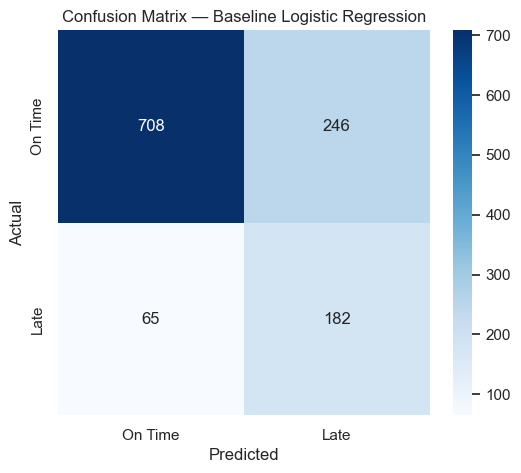

True Negatives : 708
False Positives: 246
False Negatives: 65
True Positives : 182


In [98]:
# Create confusion matrix for the baseline model
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time", "Late"],
    yticklabels=["On Time", "Late"]
)

plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Display individual values
tn, fp, fn, tp = cm_baseline.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

### Baseline Model Finding

The baseline Logistic Regression model achieved an **accuracy of 74.1%, precision of 42.5%, recall of 73.7%, and F1-score of 53.9%**.

The confusion matrix shows that the model correctly identified **182 of the 247 late shipments**, while **65 late shipments were missed**. It also generated **246 false-positive alerts** for shipments that were actually delivered on time.

For MapleFreight, recall is particularly important because a false negative represents a late shipment that dispatch would not be warned about. The baseline model therefore provides useful delay detection, but its relatively low precision indicates that many alerts would be unnecessary. A stronger model will be evaluated to determine whether this trade-off can be improved.

## 8. Random Forest Model

A Random Forest classifier is trained as an alternative to the Logistic Regression baseline. Random Forest can capture nonlinear relationships and interactions among shipment characteristics and operating conditions.

Class weighting is again used to account for the imbalance between on-time and late deliveries. The model will be evaluated using the same test set and metrics as the baseline to allow a fair comparison.

In [99]:
# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [100]:
# Make predictions using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1-score : {rf_f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.807
Precision: 0.857
Recall   : 0.073
F1-score : 0.134

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89       954
           1       0.86      0.07      0.13       247

    accuracy                           0.81      1201
   macro avg       0.83      0.53      0.51      1201
weighted avg       0.82      0.81      0.74      1201



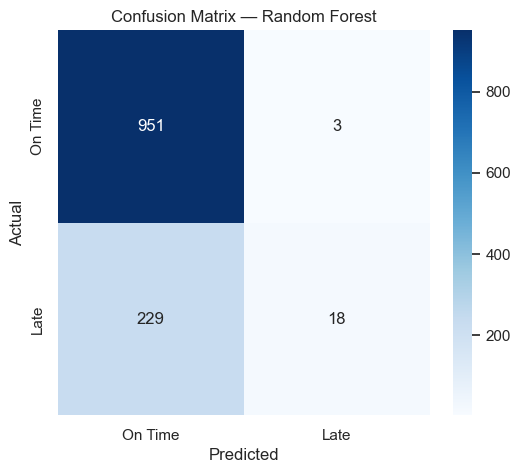

True Negatives : 951
False Positives: 3
False Negatives: 229
True Positives : 18


In [101]:
# Create confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time", "Late"],
    yticklabels=["On Time", "Late"]
)

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Display individual values
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("True Negatives :", tn_rf)
print("False Positives:", fp_rf)
print("False Negatives:", fn_rf)
print("True Positives :", tp_rf)

### Random Forest Finding

The Random Forest model achieved an accuracy of 80.7% and high precision of 85.7%. However, its recall for late deliveries was only 7.3%. The confusion matrix shows that the model correctly identified only 18 late shipments while missing 229 actual late shipments.

Although Random Forest achieved higher overall accuracy than the baseline Logistic Regression model, its very low recall makes it unsuitable for MapleFreight's operational objective. Since the goal is to identify shipments at risk of being late so that dispatch teams can take preventive action, missing late shipments is particularly costly.

In [102]:
# Compare model performance
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.741, 0.807],
    "Precision": [0.425, 0.857],
    "Recall": [0.737, 0.073],
    "F1-Score": [0.539, 0.134]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.741,0.425,0.737,0.539
1,Random Forest,0.807,0.857,0.073,0.134


### Model Comparison and Selection

The two models show very different performance. Random Forest achieved the higher overall accuracy at 80.7%, compared with 74.1% for Logistic Regression. However, accuracy alone is not the most important metric for this business problem.

Logistic Regression achieved a recall of 73.7% for late deliveries, while Random Forest achieved only 7.3%. This means Logistic Regression identifies a much larger proportion of shipments that are actually late.

For MapleFreight, failing to identify an at-risk shipment is more costly than generating an additional warning. Therefore, **Logistic Regression is selected as the preferred model** for identifying shipments that may require operational intervention and Slack alerts.

In [103]:
# Generate late-delivery probabilities using Logistic Regression
late_probabilities = baseline_model.predict_proba(X_test)[:, 1]

# Preview predicted probabilities
print("Number of predictions:", len(late_probabilities))
print("First 10 late-delivery probabilities:")
print(late_probabilities[:10])



Number of predictions: 1201
First 10 late-delivery probabilities:
[0.64398191 0.54866282 0.29241333 0.21021287 0.15164014 0.36164606
 0.64194517 0.59660793 0.59328721 0.64147338]


In [104]:
# Create a copy of the test data for risk analysis
risk_results = X_test.copy()

# Add actual delivery outcome
risk_results["actual_late"] = y_test.values

# Add predicted probability of late delivery
risk_results["late_probability"] = late_probabilities

# Mark shipments with probability >= 50% as high risk
risk_results["risk_status"] = risk_results["late_probability"].apply(
    lambda x: "High Risk" if x >= 0.50 else "Low Risk"
)

# Display the first 10 high-risk shipments
high_risk_shipments = risk_results[
    risk_results["risk_status"] == "High Risk"
].sort_values("late_probability", ascending=False)

print("Number of high-risk shipments:", len(high_risk_shipments))

high_risk_shipments.head(10)

Number of high-risk shipments: 428


,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,num_stops,...,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_late,late_probability,risk_status
1557,Montreal QC,Regina SK,Contract Owner-Op,Standard,Refrigerated,Bronze,8,856.4,1688.1,3,...,2.1,4.7,Snow,57.8,0.573,3,265.15,1,0.984098,High Risk
2112,Montreal QC,Edmonton AB,QuebecExpress,Economy,General Freight,Gold,9,1148.2,128.1,4,...,5.4,4.1,Storm,50.2,0.355,4,260.19,1,0.979637,High Risk
4615,Toronto ON,Winnipeg MB,Contract Owner-Op,Economy,General Freight,Bronze,10,694.1,956.3,4,...,3.0,2.3,Snow,65.2,0.750,3,186.18,1,0.978793,High Risk
268,Mississauga ON,Calgary AB,QuebecExpress,Economy,Refrigerated,Bronze,5,609.7,2628.3,5,...,4.9,6.5,Storm,88.5,0.132,1,203.19,1,0.977104,High Risk
4045,Montreal QC,Sudbury ON,PrairieLine,Economy,Fragile,Gold,6,944.7,2440.1,4,...,7.2,2.7,Storm,61.7,0.112,3,197.68,0,0.972037,High Risk
956,Montreal QC,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Silver,5,1897.6,1042.1,2,...,3.8,17.3,Storm,41.4,0.621,1,144.62,1,0.970766,High Risk
3645,Montreal QC,Hamilton ON,NorthStar Carriers,Standard,Refrigerated,Silver,6,1594.0,745.4,2,...,3.6,4.0,Snow,84.0,0.551,0,176.14,1,0.970626,High Risk
554,Mississauga ON,Winnipeg MB,NorthStar Carriers,Standard,General Freight,Bronze,5,780.1,1737.3,5,...,1.1,2.8,Snow,63.1,0.673,3,181.15,1,0.967652,High Risk
5562,Winnipeg MB,Quebec City QC,NorthStar Carriers,Express,General Freight,Silver,12,830.0,442.4,4,...,2.5,3.5,Snow,72.8,0.152,4,151.59,1,0.966700,High Risk
940,Toronto ON,Sudbury ON,Contract Owner-Op,Standard,General Freight,Silver,10,1065.5,1753.6,2,...,6.9,9.9,Snow,74.3,0.764,2,251.00,1,0.966443,High Risk


In [105]:
# Create a simplified table for operational alerts
alert_table = high_risk_shipments[
    [
        "origin_city",
        "destination_city",
        "carrier",
        "service_level",
        "weather_condition",
        "pickup_delay_minutes",
        "traffic_index",
        "late_probability",
        "risk_status"
    ]
].copy()

# Convert probability to percentage
alert_table["late_probability"] = (
    alert_table["late_probability"] * 100
).round(1)

alert_table = alert_table.rename(
    columns={"late_probability": "late_risk_percent"}
)

# Display the 10 highest-risk shipments
alert_table.head(10)

,origin_city,destination_city,carrier,service_level,weather_condition,pickup_delay_minutes,traffic_index,late_risk_percent,risk_status
1557,Montreal QC,Regina SK,Contract Owner-Op,Standard,Snow,37.0,57.8,98.4,High Risk
2112,Montreal QC,Edmonton AB,QuebecExpress,Economy,Storm,18.0,50.2,98.0,High Risk
4615,Toronto ON,Winnipeg MB,Contract Owner-Op,Economy,Snow,-20.0,65.2,97.9,High Risk
268,Mississauga ON,Calgary AB,QuebecExpress,Economy,Storm,-7.0,88.5,97.7,High Risk
4045,Montreal QC,Sudbury ON,PrairieLine,Economy,Storm,5.0,61.7,97.2,High Risk
956,Montreal QC,Sudbury ON,MapleFreight Fleet,Standard,Storm,10.0,41.4,97.1,High Risk
3645,Montreal QC,Hamilton ON,NorthStar Carriers,Standard,Snow,17.0,84.0,97.1,High Risk
554,Mississauga ON,Winnipeg MB,NorthStar Carriers,Standard,Snow,81.0,63.1,96.8,High Risk
5562,Winnipeg MB,Quebec City QC,NorthStar Carriers,Express,Snow,119.0,72.8,96.7,High Risk
940,Toronto ON,Sudbury ON,Contract Owner-Op,Standard,Snow,6.0,74.3,96.6,High Risk


In [106]:
# Select the highest-risk shipment
top_risk = alert_table.iloc[0]

# Create Slack-style alert message
slack_message = f"""
🚨 MAPLEFREIGHT HIGH-RISK DELIVERY ALERT 🚨

Route: {top_risk['origin_city']} → {top_risk['destination_city']}
Carrier: {top_risk['carrier']}
Service Level: {top_risk['service_level']}
Weather: {top_risk['weather_condition']}
Pickup Delay: {top_risk['pickup_delay_minutes']} minutes
Traffic Index: {top_risk['traffic_index']}
Predicted Late-Delivery Risk: {top_risk['late_risk_percent']}%

Recommended Action:
Review this shipment and take preventive action to reduce the risk of late delivery.
"""

print(slack_message)


🚨 MAPLEFREIGHT HIGH-RISK DELIVERY ALERT 🚨

Route: Montreal QC → Regina SK
Carrier: Contract Owner-Op
Service Level: Standard
Weather: Snow
Pickup Delay: 37.0 minutes
Traffic Index: 57.8
Predicted Late-Delivery Risk: 98.4%

Recommended Action:
Review this shipment and take preventive action to reduce the risk of late delivery.



### Slack Alert Logic

The selected Logistic Regression model generates a probability that each shipment will be delivered late. Shipments with a predicted late-delivery probability of **50% or greater** are classified as high risk and become candidates for operational alerts.

The alert provides dispatch teams with important shipment information, including the route, carrier, service level, weather condition, pickup delay, traffic conditions, and predicted late-delivery risk. This allows the operations team to investigate high-risk shipments and take preventive action before the delivery is completed.

In this analysis, **428 shipments** in the test dataset were classified as high risk. To avoid overwhelming dispatch teams with excessive alerts, the highest-risk shipments can be prioritized for notification.

## 11. Model Explainability

To understand which factors contribute most to delivery-delay predictions, feature importance is examined for the Random Forest model. This helps identify the shipment, route, carrier, and operating conditions that have the strongest influence on predicted delivery risk.

In [107]:
# Extract feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance values from the Random Forest model
feature_importance = rf_model.named_steps["classifier"].feature_importances_

# Create a DataFrame of feature importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
}).sort_values("Importance", ascending=False)

# Display the 15 most important features
importance_df.head(15)

,Feature,Importance
5,num__scheduled_transit_hours,0.082468
9,num__traffic_index,0.080866
1,num__distance_km,0.073565
6,num__pickup_delay_minutes,0.067402
10,num__route_congestion_score,0.063502
7,num__driver_experience_years,0.059404
2,num__weight_kg,0.052983
12,num__fuel_cost_cad,0.052428
8,num__vehicle_age_years,0.052086
3,num__num_stops,0.041828


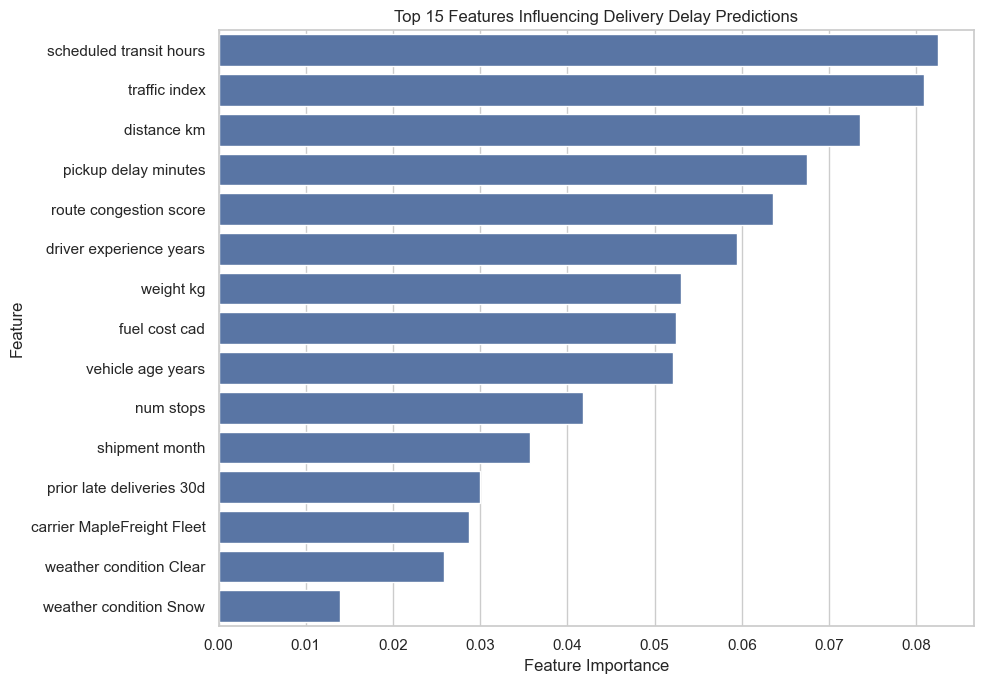

In [108]:
# Select the 15 most important features
top_features = importance_df.head(15).copy()

# Clean feature names for easier reading
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Plot feature importance
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Delivery Delay Predictions")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Finding

The Random Forest feature importance analysis shows that scheduled transit time, traffic conditions, shipment distance, pickup delay, and route congestion are among the strongest factors influencing delivery-delay predictions. Scheduled transit hours and traffic index have the highest importance, indicating that route timing and operating conditions play a major role in identifying shipments at risk of being late.

Carrier and weather-related features also contribute to the predictions, although their individual importance is lower than the main numerical factors. These findings support using real-time operational information such as traffic, pickup delays, and route conditions when identifying high-risk shipments.

## 12. Slack Alert Integration

High-risk shipment predictions are integrated with Slack so that the dispatch team can be notified while there is still time to take preventive action. A Slack incoming webhook is used to send a concise alert containing the number of high-risk shipments and details of the highest-risk deliveries.

The webhook credential is stored separately from the notebook and is not included in the GitHub repository.

In [109]:
!pip install python-dotenv


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [110]:
import os
from dotenv import load_dotenv

load_dotenv()

webhook_url = os.getenv("SLACK_WEBHOOK_URL")

if webhook_url:
    print("Slack webhook loaded successfully.")
else:
    print("Slack webhook was NOT found.")

Slack webhook loaded successfully.


In [111]:
import requests

test_message = {
    "text": "🚚 MapleFreight Delivery Alert System connected successfully!"
}

response = requests.post(
    webhook_url,
    json=test_message,
    timeout=10
)

if response.status_code == 200:
    print("Slack test alert sent successfully!")
else:
    print("Slack alert failed. Status code:", response.status_code)

Slack test alert sent successfully!


In [112]:
print(alert_table.columns.tolist())

['origin_city', 'destination_city', 'carrier', 'service_level', 'weather_condition', 'pickup_delay_minutes', 'traffic_index', 'late_risk_percent', 'risk_status']


In [113]:
print(df.columns.tolist())

['shipment_id', 'origin_city', 'destination_city', 'carrier', 'service_level', 'goods_type', 'customer_priority_tier', 'shipment_month', 'distance_km', 'weight_kg', 'num_stops', 'is_cross_border', 'scheduled_transit_hours', 'pickup_delay_minutes', 'driver_experience_years', 'vehicle_age_years', 'weather_condition', 'traffic_index', 'route_congestion_score', 'prior_late_deliveries_30d', 'fuel_cost_cad', 'actual_transit_hours', 'delivered_late']


In [114]:
alert_table = alert_table.copy()

alert_table.insert(
    0,
    "shipment_id",
    df.loc[alert_table.index, "shipment_id"]
)

alert_table.head(10)

,shipment_id,origin_city,destination_city,carrier,service_level,weather_condition,pickup_delay_minutes,traffic_index,late_risk_percent,risk_status
1557,SHP-103230,Montreal QC,Regina SK,Contract Owner-Op,Standard,Snow,37.0,57.8,98.4,High Risk
2112,SHP-102910,Montreal QC,Edmonton AB,QuebecExpress,Economy,Storm,18.0,50.2,98.0,High Risk
4615,SHP-103231,Toronto ON,Winnipeg MB,Contract Owner-Op,Economy,Snow,-20.0,65.2,97.9,High Risk
268,SHP-105927,Mississauga ON,Calgary AB,QuebecExpress,Economy,Storm,-7.0,88.5,97.7,High Risk
4045,SHP-100014,Montreal QC,Sudbury ON,PrairieLine,Economy,Storm,5.0,61.7,97.2,High Risk
956,SHP-101710,Montreal QC,Sudbury ON,MapleFreight Fleet,Standard,Storm,10.0,41.4,97.1,High Risk
3645,SHP-100273,Montreal QC,Hamilton ON,NorthStar Carriers,Standard,Snow,17.0,84.0,97.1,High Risk
554,SHP-103300,Mississauga ON,Winnipeg MB,NorthStar Carriers,Standard,Snow,81.0,63.1,96.8,High Risk
5562,SHP-103965,Winnipeg MB,Quebec City QC,NorthStar Carriers,Express,Snow,119.0,72.8,96.7,High Risk
940,SHP-101673,Toronto ON,Sudbury ON,Contract Owner-Op,Standard,Snow,6.0,74.3,96.6,High Risk


In [115]:
# Create a phone-friendly Slack alert for high-risk shipments

top_alerts = alert_table.sort_values(
    "late_risk_percent",
    ascending=False
).head(5)

message_lines = [
    "🚨 *MapleFreight High-Risk Delivery Alert*",
    f"*{len(alert_table)} shipments* have been identified as high risk.",
    "",
    "*Top 5 shipments requiring attention:*"
]

for _, row in top_alerts.iterrows():
    message_lines.append(
        f"• *{row['shipment_id']}* | "
        f"{row['destination_city']} | "
        f"{row['carrier']} | "
        f"*{row['late_risk_percent']:.1f}% risk*"
    )

message_lines.append("")
message_lines.append("⚠️ Dispatch team: Please review these shipments for possible intervention.")

slack_message = "\n".join(message_lines)

response = requests.post(
    webhook_url,
    json={"text": slack_message},
    timeout=10
)

if response.status_code == 200:
    print("High-risk shipment alert sent successfully!")
else:
    print("Slack alert failed. Status code:", response.status_code)

High-risk shipment alert sent successfully!


In [116]:
%%writefile .gitignore
.env
.ipynb_checkpoints/
__pycache__/

Overwriting .gitignore


In [117]:
%%writefile .env.example
SLACK_WEBHOOK_URL=your_slack_webhook_url_here

Overwriting .env.example


In [118]:
%%writefile requirements.txt
pandas
numpy
matplotlib
scikit-learn
requests
python-dotenv

Overwriting requirements.txt


In [119]:
import os

os.makedirs("screenshots", exist_ok=True)

print("screenshots folder created successfully!")

screenshots folder created successfully!


In [120]:
%%writefile README.md
# MapleFreight Delivery Delay Prediction & Slack Alerts

**Student Name:** Diksha Sharma  
**Student ID:** c0965344  
**Course:** AML 3303  

## Project Overview

MapleFreight Logistics handles approximately 8,000 shipments per week across Ontario, Quebec, and the Prairies. Its on-time delivery performance has decreased from 94% to 88%.

This project develops a machine learning solution to identify in-transit shipments that are at high risk of arriving late. High-risk shipments are automatically communicated to the dispatch team through Slack so that corrective action can be taken before the promised delivery window is missed.

## Dataset

The dataset contains shipment, route, carrier, service-level, weather, traffic, vehicle, driver, and operational information.

The target variable is `delivered_late`, where:

- `0` = shipment delivered on time
- `1` = shipment delivered late

The post-delivery variable `actual_transit_hours` was excluded from the predictive features to prevent data leakage.

## Data Preparation

The project includes:

- Missing-value handling
- Duplicate removal
- Category standardization
- Data-quality checks
- Numerical and categorical preprocessing
- One-hot encoding of categorical variables
- Train/test splitting
- Class-imbalance handling

## Exploratory Data Analysis

EDA identified several factors associated with late deliveries.

Key observations included:

- Economy shipments had the highest late-delivery rate at approximately 26.56%.
- Late shipments had a higher average pickup delay.
- Late shipments experienced higher average traffic levels.
- Route congestion was higher among late shipments.
- Shipments with more prior late deliveries also showed increased risk.

## Machine Learning Models

Two classification approaches were evaluated:

### Logistic Regression

The Logistic Regression baseline produced approximately:

- Accuracy: 0.741
- Precision: 0.425
- Recall: 0.737
- F1-score: 0.539

The relatively high recall makes this model useful for identifying shipments that may require intervention.

### Random Forest

The Random Forest model produced approximately:

- Accuracy: 0.807
- Precision: 0.857
- Recall: 0.073
- F1-score: 0.134

Although Random Forest achieved higher overall accuracy and precision at the default threshold, its recall was very low. This demonstrates why accuracy alone is not an appropriate metric for this imbalanced business problem.

## Model Explainability

Random Forest feature importance was used to investigate the variables influencing predictions.

Important features included:

- Scheduled transit hours
- Traffic index
- Distance
- Pickup delay
- Route congestion
- Driver experience
- Shipment weight
- Fuel cost
- Vehicle age
- Number of stops

These findings can help dispatch teams understand operational conditions associated with delivery risk.

## Slack Alert Integration

A Slack Incoming Webhook was integrated with the prediction workflow.

High-risk shipments are sent to the private `#dispatch-alerts` channel. The alert includes:

- Number of high-risk shipments
- Shipment ID
- Destination
- Carrier
- Predicted late-delivery risk

The system identified 428 high-risk shipments in the evaluated set and sent the five highest-risk shipments to Slack for dispatch review.

Evidence of the working integration is available at:

`screenshots/slack_alert.png`

The Slack webhook URL is stored locally in a `.env` file and is not committed to the repository.

## Security

The project uses environment variables to protect the Slack webhook credential.

The repository includes:

- `.gitignore` to exclude `.env`
- `.env.example` showing the required variable name
- No Slack webhook URL in the notebook or repository

## Running the Project

Install the required packages using:

`pip install -r requirements.txt`

Create a local `.env` file containing:

`SLACK_WEBHOOK_URL=your_actual_slack_webhook_url`

Then run the notebook from top to bottom.

## Business Recommendations

MapleFreight should prioritize shipments with high predicted late-delivery risk for proactive dispatch intervention. Particular attention should be given to pickup delays, heavy traffic, congested routes, service level, and shipments with a history of late deliveries.

Potential interventions include rerouting shipments, contacting carriers, adjusting dispatch priorities, and proactively notifying customers.

## AI Assistant Disclosure

An AI assistant (ChatGPT) was used during the project for guidance with code structure, debugging, interpretation of model results, documentation, and Slack integration.

One AI-generated suggestion incorrectly referred to the Random Forest pipeline using the variable name `model_rf`, while the actual pipeline in the notebook was named `rf_model`. This caused a `NameError`. The issue was identified by checking the previously defined model variable and correcting the code to use `rf_model`.

AI-generated suggestions were reviewed and tested before being incorporated into the final project.

## Project Files

- `MapleFreight_Delivery_Delay_Prediction_c0965344.ipynb` - complete analysis and modelling notebook
- `README.md` - project documentation
- `requirements.txt` - Python dependencies
- `.env.example` - environment-variable template
- `.gitignore` - excludes private environment files
- `screenshots/slack_alert.png` - evidence of successful Slack alert

Overwriting README.md


In [121]:

!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .gitignore
	modified:   README.md
	modified:   notebook/Assignment1_DikshaSharma.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.env.example
	MapleFreight_Delivery_Delay_Prediction_c0965344.ipynb
	README_old_social_media.md
	notebook/maplefreight_delivery_delay_dataset.csv
	notebook/untitled.py
	requirements.txt
	screenshots/

no changes added to commit (use "git add" and/or "git commit -a")


In [122]:
!git check-ignore -v .env

.gitignore:1:.env	.env


In [123]:
!git add .gitignore
!git add .env.example
!git add README.md
!git add requirements.txt
!git add MapleFreight_Delivery_Delay_Prediction_c0965344.ipynb
!git add notebook/maplefreight_delivery_delay_dataset.csv
!git add screenshots/slack_alert.png

In [124]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .env.example
	modified:   .gitignore
	new file:   MapleFreight_Delivery_Delay_Prediction_c0965344.ipynb
	modified:   README.md
	new file:   notebook/maplefreight_delivery_delay_dataset.csv
	new file:   requirements.txt
	new file:   screenshots/slack_alert.png

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebook/Assignment1_DikshaSharma.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	README_old_social_media.md
	notebook/untitled.py



In [125]:
!git commit -m "Complete MapleFreight delivery delay prediction project"

[main af5dd41] Complete MapleFreight delivery delay prediction project
 7 files changed, 10681 insertions(+), 143 deletions(-)
 create mode 100644 .env.example
 create mode 100644 MapleFreight_Delivery_Delay_Prediction_c0965344.ipynb
 create mode 100644 notebook/maplefreight_delivery_delay_dataset.csv
 create mode 100644 requirements.txt
 create mode 100644 screenshots/slack_alert.png


In [127]:
!git push origin main

Everything up-to-date
